# CREMA-D — EDA, Cleaning & Preprocessing

**Dataset**: Crowd-sourced Emotional Multimodal Actors Dataset
**Role in EmoCare**: Speech emotion dataset adding demographic diversity (91 actors)

## 0. Imports & Paths

In [1]:
import os, sys, glob, re, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import librosa, librosa.display

PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
RAW_DIR       = os.path.join(PROJECT_ROOT, 'data', 'raw', 'crema_d')
AUDIO_DIR     = os.path.join(RAW_DIR, 'AudioWAV')
INTERIM_DIR   = os.path.join(PROJECT_ROOT, 'data', 'interim')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
os.makedirs(INTERIM_DIR,   exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

EMOTION_CODE_MAP = {'ANG':'angry', 'DIS':'disgust', 'FEA':'fearful', 'HAP':'happy', 'NEU':'neutral', 'SAD':'sad'}
print('Project root:', PROJECT_ROOT)

Project root: D:\EmoCare


## 1. Load Metadata & Demographics

In [2]:
df_demo = pd.read_csv(os.path.join(RAW_DIR, 'VideoDemographics.csv'))
all_wavs = glob.glob(os.path.join(AUDIO_DIR, '*.wav'))
records = []
for fp in all_wavs:
    fname = os.path.basename(fp).replace('.wav', '')
    parts = fname.split('_')
    if len(parts) >= 3:
        records.append({
            'filepath': fp, 'filename': os.path.basename(fp),
            'actor_id': int(parts[0]), 'sentence': parts[1],
            'emotion_code': parts[2], 'emotion': EMOTION_CODE_MAP.get(parts[2], 'unknown'),
            'level': parts[3] if len(parts) > 3 else 'XX'
        })
df_meta = pd.DataFrame(records).merge(df_demo.rename(columns={'ActorID': 'actor_id'}), on='actor_id', how='left')
print('CREMA-D parsed records:', len(df_meta))
df_meta.head()

CREMA-D parsed records: 7442


,filepath,filename,actor_id,sentence,emotion_code,emotion,level,Age,Sex,Race,Ethnicity
0,D:\EmoCare\data\raw\crema_d\AudioWAV\1001_DFA_...,1001_DFA_ANG_XX.wav,1001,DFA,ANG,angry,XX,51,Male,Caucasian,Not Hispanic
1,D:\EmoCare\data\raw\crema_d\AudioWAV\1001_DFA_...,1001_DFA_DIS_XX.wav,1001,DFA,DIS,disgust,XX,51,Male,Caucasian,Not Hispanic
2,D:\EmoCare\data\raw\crema_d\AudioWAV\1001_DFA_...,1001_DFA_FEA_XX.wav,1001,DFA,FEA,fearful,XX,51,Male,Caucasian,Not Hispanic
3,D:\EmoCare\data\raw\crema_d\AudioWAV\1001_DFA_...,1001_DFA_HAP_XX.wav,1001,DFA,HAP,happy,XX,51,Male,Caucasian,Not Hispanic
4,D:\EmoCare\data\raw\crema_d\AudioWAV\1001_DFA_...,1001_DFA_NEU_XX.wav,1001,DFA,NEU,neutral,XX,51,Male,Caucasian,Not Hispanic


## 2. EDA — Class Distribution & Demographics

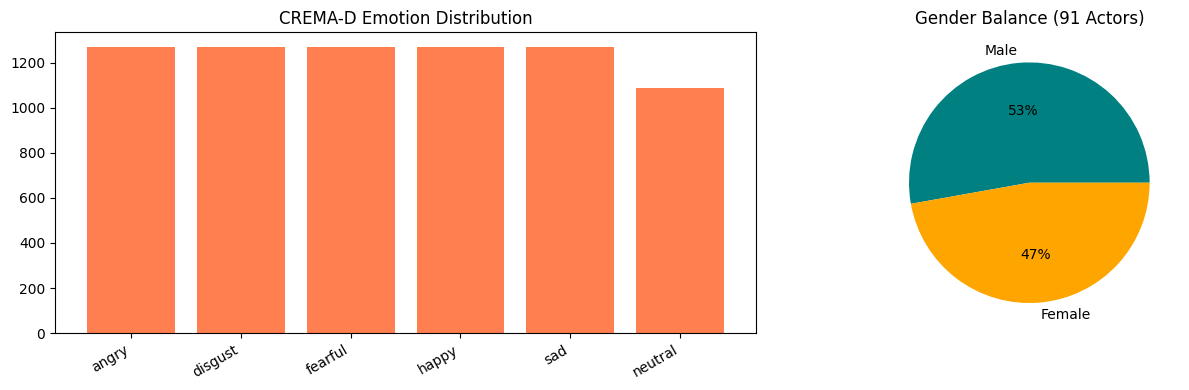

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
emo_counts = df_meta['emotion'].value_counts()
axes[0].bar(emo_counts.index, emo_counts.values, color='coral')
axes[0].set_title('CREMA-D Emotion Distribution')
axes[0].set_xticklabels(emo_counts.index, rotation=30, ha='right')
df_meta['Sex'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.0f%%', colors=['teal', 'orange'])
axes[1].set_title('Gender Balance (91 Actors)')
plt.tight_layout()
plt.savefig(os.path.join(INTERIM_DIR, 'cremad_distributions.png'), dpi=150)
plt.show()

## 3. Acoustic Features & Combined Speech Dataset

In [4]:
feat_path = os.path.join(PROCESSED_DIR, 'cremad_features.csv')
df_features = pd.read_csv(feat_path)
print('Loaded pre-extracted CREMA-D features:', len(df_features), 'records | Shape:', df_features.shape)
df_features.head()

Loaded pre-extracted CREMA-D features: 7442 records | Shape: (7442, 101)


,mfcc_0_mean,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,...,chroma_mean,chroma_std,duration_s,pause_ratio,filename,actor_id,emotion_code,emotion,level,split
0,-306.027405,159.390335,92.670235,28.411352,8.491312,32.853794,23.965403,18.576996,7.477993,17.579239,...,0.411293,0.289385,2.275562,0.497322,1001_DFA_ANG_XX.wav,1001,ANG,angry,XX,train
1,-335.495911,107.470993,100.393311,25.014709,9.384935,24.072784,30.160904,13.558439,11.466775,15.904690,...,0.401279,0.290594,2.035375,0.297365,1001_DFA_NEU_XX.wav,1001,NEU,neutral,XX,train
2,-365.185608,103.046768,97.092560,27.136665,15.737350,23.611780,34.221027,15.302605,18.323439,10.936809,...,0.427224,0.275347,2.002000,0.245161,1001_DFA_SAD_XX.wav,1001,SAD,sad,XX,train
3,-270.180328,142.899689,92.644684,28.764816,4.134922,34.006321,10.847631,28.079359,-8.362823,36.265999,...,0.384599,0.293414,1.935250,0.479815,1001_IEO_ANG_HI.wav,1001,ANG,angry,HI,train
4,-360.066223,110.904724,109.193436,19.370699,12.335657,25.018030,22.731333,14.903253,6.942801,29.069513,...,0.431309,0.287792,2.068750,0.289124,1001_IEO_ANG_LO.wav,1001,ANG,angry,LO,train


In [5]:
comb_path = os.path.join(PROCESSED_DIR, 'speech_combined.csv')
df_comb = pd.read_csv(comb_path, low_memory=False)
print('Combined Speech Dataset Shape:', df_comb.shape)
print('Source Breakdown:')
print(df_comb['source'].value_counts())
print('Emotion Breakdown by Dataset:')
print(df_comb.groupby(['source', 'emotion']).size().unstack(fill_value=0))

Combined Speech Dataset Shape: (8882, 106)
Source Breakdown:
source
CREMA-D    7442
RAVDESS    1440
Name: count, dtype: int64
Emotion Breakdown by Dataset:
emotion  angry  calm  disgust  fearful  happy  neutral   sad  surprised
source                                                                 
CREMA-D   1271     0     1271     1271   1271     1087  1271          0
RAVDESS    192   192      192      192    192       96   192        192
